# Parte 1. Concatenar CSVs

In [84]:
import os
import pandas as pd

base_dir = "outputs/por_chico"

dfs = []

for root, dirs, files in os.walk(base_dir):
    for fname in files:
        if not fname.lower().endswith(".csv"):
            continue
        if not fname.startswith("df_results_"):
            continue

        filepath = os.path.join(root, fname)

        name_no_ext = os.path.splitext(fname)[0]
        name_core = name_no_ext.replace("df_results_", "", 1)

        partes = name_core.split("-")

        nombre = partes[0] if len(partes) > 0 else ""
        numero_audio = partes[1] if len(partes) > 1 else ""
        nivel_socio = partes[2] if len(partes) > 2 else ""

        df = pd.read_csv(filepath)

        df["nombre"] = nombre
        df["numero_audio"] = numero_audio
        df["nivel_socio"] = nivel_socio
        df["archivo_origen"] = fname
        df["carpeta_origen"] = os.path.basename(root)

        cols_first = ["nombre", "numero_audio", "nivel_socio", "archivo_origen", "carpeta_origen"]
        other_cols = [c for c in df.columns if c not in cols_first]
        df = df[cols_first + other_cols]

        dfs.append(df)

df_resultados_concat = pd.concat(dfs, ignore_index=True)

print("Filas:", len(df_resultados_concat))
print("Chicos únicos:", df_resultados_concat["nombre"].nunique())

Filas: 5088002
Chicos únicos: 24


# Parte 2. Guardar concatenado

In [85]:
import os
import math

output_dir = "outputs/final_concats"
os.makedirs(output_dir, exist_ok=True)

# Límite seguro: 85 MB
max_size_bytes = 85 * 1024 * 1024

sample_n = min(10000, len(df_resultados_concat))

if sample_n == 0:
    print("DataFrame vacío.")
else:
    # --- Estimación inicial ---
    sample_df = df_resultados_concat.iloc[:sample_n]
    temp_path = os.path.join(output_dir, "_tmp_sample.csv")
    sample_df.to_csv(temp_path, index=False)
    sample_size = os.path.getsize(temp_path)
    os.remove(temp_path)

    bytes_per_row = sample_size / sample_n
    rows_per_file_est = max(1, int(max_size_bytes / bytes_per_row))

    print(f"Estimación inicial de filas por archivo: {rows_per_file_est}")

    start = 0
    part = 1
    total_rows = len(df_resultados_concat)

    while start < total_rows:
        end = min(start + rows_per_file_est, total_rows)

        # Primer intento
        chunk = df_resultados_concat.iloc[start:end]
        output_csv = os.path.join(output_dir, f"df_resultados_concat_part_{part}.csv")
        chunk.to_csv(output_csv, index=False)

        # Si se pasa, achicar hasta cumplir
        while os.path.getsize(output_csv) > max_size_bytes:
            os.remove(output_csv)

            # achicar un 10% cada vez
            new_rows = max(1, int((end - start) * 0.9))
            end = start + new_rows

            chunk = df_resultados_concat.iloc[start:end]
            chunk.to_csv(output_csv, index=False)

            # seguridad extra por si una sola fila fuera enorme
            if end == start + 1 and os.path.getsize(output_csv) > max_size_bytes:
                raise ValueError(
                    f"La fila en posición {start} sola supera el límite de {max_size_bytes} bytes."
                )

        final_size_mb = os.path.getsize(output_csv) / (1024 * 1024)
        print(
            f"Archivo {part}: filas {start} a {end-1} | "
            f"{end-start} filas | {final_size_mb:.2f} MB"
        )

        start = end
        part += 1

print("Archivos divididos correctamente.")

Estimación inicial de filas por archivo: 1272928
Archivo 1: filas 0 a 1145634 | 1145635 filas | 83.85 MB
Archivo 2: filas 1145635 a 2291269 | 1145635 filas | 82.89 MB
Archivo 3: filas 2291270 a 3322340 | 1031071 filas | 77.31 MB
Archivo 4: filas 3322341 a 4467975 | 1145635 filas | 84.36 MB
Archivo 5: filas 4467976 a 5088001 | 620026 filas | 46.37 MB
Archivos divididos correctamente.


In [86]:
df = df_resultados_concat.copy()

# filas con al menos un NaN
df_nan = df[df.isna().any(axis=1)]

# chicos con NaN
chicos_con_nan = df_nan["nombre"].unique()

print("Chicos con al menos un NaN:")
print(chicos_con_nan)
print(f"\nCantidad: {len(chicos_con_nan)}")

Chicos con al menos un NaN:
[]

Cantidad: 0


# Análisis con todos los chicos

In [87]:
import numpy as np

df = df_resultados_concat.copy()

cols_elan = ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL"]
cols_diar = ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SPEECH"]

# SIL en Elan
df["Elan_SIL"] = (df[cols_elan].eq(0).all(axis=1)).astype(int)

# SIL en Diar
df["Diar_SIL"] = 1 - df["Diar_SPEECH"]

# Parte 4. Armar multilabel SIN ELE

In [88]:
labels = ["KCHI", "OCH", "FEM", "MAL", "SIL"]

y_true_multi = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL", "Elan_SIL"]
].values

y_pred_multi = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SIL"]
].values

# Parte 5. Multilabel confusion + report

In [89]:
# índices de las clases que forman SPEECH
speech_indices = [labels.index(l) for l in ["KCHI", "OCH", "FEM", "MAL"]]

# crear columna SPEECH
y_true_speech = (y_true_multi[:, speech_indices].sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_multi[:, speech_indices].sum(axis=1) > 0).astype(int)

# agregar como nueva columna
y_true_multi = np.hstack([y_true_multi, y_true_speech.reshape(-1, 1)])
y_pred_multi = np.hstack([y_pred_multi, y_pred_speech.reshape(-1, 1)])

# agregar label
labels = labels + ["SPEECH"]

conf_matrix = multilabel_confusion_matrix(y_true_multi, y_pred_multi)

for i, label in enumerate(labels):
    print(f"\nMatriz para {label}:")
    print(conf_matrix[i])

print("\nReporte multilabel:")

# 🔽 CAMBIO ACÁ
report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report).T

# pasar a porcentaje con 1 decimal
cols = ['precision', 'recall', 'f1-score']
df_report[cols] = (df_report[cols] * 100).round(1).astype(str) + "%"

print(df_report)


Matriz para KCHI:
[[4273973  321746]
 [ 184328  307955]]

Matriz para OCH:
[[4392988  334614]
 [ 229218  131182]]

Matriz para FEM:
[[3713063  583970]
 [ 330926  460043]]

Matriz para MAL:
[[4612210  182323]
 [ 176535  116934]]

Matriz para SIL:
[[1345198  389807]
 [1127568 2225429]]

Matriz para SPEECH:
[[2447880  905117]
 [ 501023 1233982]]

Reporte multilabel:
             precision recall f1-score    support
KCHI             48.9%  62.6%    54.9%   492283.0
OCH              28.2%  36.4%    31.8%   360400.0
FEM              44.1%  58.2%    50.1%   790969.0
MAL              39.1%  39.8%    39.5%   293469.0
SIL              85.1%  66.4%    74.6%  3352997.0
SPEECH           57.7%  71.1%    63.7%  1735005.0
micro avg        62.2%  63.7%    63.0%  7025123.0
macro avg        50.5%  55.7%    52.4%  7025123.0
weighted avg     66.3%  63.7%    64.1%  7025123.0
samples avg      63.7%  64.9%    64.0%  7025123.0


## Análisis solo con los ACLEW 

In [112]:
import numpy as np
import pandas as pd
import re
from sklearn.metrics import multilabel_confusion_matrix, classification_report

# =========================
# 1) Copia y filtro de chicos
# =========================
df = df_resultados_concat.copy()

chicos_excluir = ["jeremiasc", "valentina", "brandona", "bautistad", "camilob"]

def extraer_chico_base(x):
    x = str(x).strip().lower()
    m = re.match(r"^(.*?)-a\d+-ns[mb]$", x)
    if m:
        return m.group(1)
    return x

df["chico"] = df["nombre"].apply(extraer_chico_base)

df = df[~df["chico"].isin(chicos_excluir)].copy()

print("Filas luego del filtro:", len(df))
print("Chicos excluidos que siguen presentes:", df["chico"].isin(chicos_excluir).sum())

# =========================
# 2) Definir columnas base
# =========================
cols_elan = ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL"]
cols_diar = ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SPEECH"]

# =========================
# 3) Crear SIL
# =========================
df["Elan_SIL"] = (df[cols_elan].eq(0).all(axis=1)).astype(int)
df["Diar_SIL"] = 1 - df["Diar_SPEECH"]

# =========================
# 4) Armar multilabel base
#    base = KCHI, OCH, FEM, MAL, SIL
# =========================
labels_base = ["KCHI", "OCH", "FEM", "MAL", "SIL"]

y_true_multi_base = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL", "Elan_SIL"]
].values

y_pred_multi_base = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SIL"]
].values

# =========================
# 5) Crear SPEECH a partir de KCHI/OCH/FEM/MAL
# =========================
speech_indices = [labels_base.index(l) for l in ["KCHI", "OCH", "FEM", "MAL"]]

y_true_speech = (y_true_multi_base[:, speech_indices].sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_multi_base[:, speech_indices].sum(axis=1) > 0).astype(int)

# =========================
# 6) Construir multilabel final
#    SIN SIL y en el orden correcto:
#    KCHI, OCH, MAL, FEM, SPEECH
# =========================
y_true_multi = np.column_stack([
    y_true_multi_base[:, 0],  # KCHI
    y_true_multi_base[:, 1],  # OCH
    y_true_multi_base[:, 3],  # MAL
    y_true_multi_base[:, 2],  # FEM
    y_true_speech             # SPEECH
])

y_pred_multi = np.column_stack([
    y_pred_multi_base[:, 0],  # KCHI
    y_pred_multi_base[:, 1],  # OCH
    y_pred_multi_base[:, 3],  # MAL
    y_pred_multi_base[:, 2],  # FEM
    y_pred_speech             # SPEECH
])

labels = ["KCHI", "OCH", "MAL", "FEM", "SPEECH"]

print("shape y_true_multi:", y_true_multi.shape)
print("shape y_pred_multi:", y_pred_multi.shape)
print("labels:", labels)

# =========================
# 7) Matrices de confusión multilabel
# =========================
conf_matrix = multilabel_confusion_matrix(y_true_multi, y_pred_multi)

for i, label in enumerate(labels):
    print(f"\nMatriz para {label}:")
    print(conf_matrix[i])

# =========================
# 8) Reporte multilabel
# =========================
print("\nReporte multilabel:")

report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report).T

# pasar a porcentaje con 1 decimal
cols = ["precision", "recall", "f1-score"]
df_report[cols] = (df_report[cols] * 100).round(1).astype(str) + "%"

print(df_report)

Filas luego del filtro: 3408002
Chicos excluidos que siguen presentes: 0
shape y_true_multi: (3408002, 5)
shape y_pred_multi: (3408002, 5)
labels: ['KCHI', 'OCH', 'MAL', 'FEM', 'SPEECH']

Matriz para KCHI:
[[2917413  157311]
 [  88300  244978]]

Matriz para OCH:
[[2993418  166471]
 [ 155485   92628]]

Matriz para MAL:
[[3049672  109115]
 [ 153352   95863]]

Matriz para FEM:
[[2516294  273821]
 [ 233469  384418]]

Matriz para SPEECH:
[[1749356  353398]
 [ 313348  991900]]

Reporte multilabel:
             precision recall f1-score    support
KCHI             60.9%  73.5%    66.6%   333278.0
OCH              35.8%  37.3%    36.5%   248113.0
MAL              46.8%  38.5%    42.2%   249215.0
FEM              58.4%  62.2%    60.2%   617887.0
SPEECH           73.7%  76.0%    74.8%  1305248.0
micro avg        63.1%  65.7%    64.4%  2753741.0
macro avg        55.1%  57.5%    56.1%  2753741.0
weighted avg     62.9%  65.7%    64.2%  2753741.0
samples avg      25.0%  25.4%    25.0%  2753741.0


## ANÁLISIS POR NIVEL SOCIOECONÓMICO


In [113]:
df_frames = (
    df_resultados_concat
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

df_frames.sort_values("n_frames")

,nombre,numero_audio,nivel_socio,n_frames
18,verag,a2,nsm,168000
16,ummaq,a2,nsb,180000
15,manuelc,a2,nsm,180000
14,lucior,a2,nsm,180000
13,lucasyoelp,a2,nsb,180000
12,lisandroh,a2,nsm,180000
11,julietap,a1,nsm,180000
10,gaell,a2,nsb,180000
17,valentinos,a1,nsb,180000
0,alma,a1,nsb,180000


In [114]:
chicos_excluir = ["jeremiasc", "valentina", "brandona"]

df_frames = (
    df_resultados_concat[
        ~df_resultados_concat["nombre"].isin(chicos_excluir)
    ]
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

df_frames = df_frames.sort_values("n_frames")
df_frames

,nombre,numero_audio,nivel_socio,n_frames
18,verag,a2,nsm,168000
16,ummaq,a2,nsb,180000
15,manuelc,a2,nsm,180000
14,lucior,a2,nsm,180000
13,lucasyoelp,a2,nsb,180000
12,lisandroh,a2,nsm,180000
11,julietap,a1,nsm,180000
10,gaell,a2,nsb,180000
17,valentinos,a1,nsb,180000
0,alma,a1,nsb,180000


In [115]:
df_frames.groupby("nivel_socio")["n_frames"].describe()

,count,mean,std,min,25%,50%,75%,max
nivel_socio,,,,,,,,
nsb,9.0,180000.0,0.000000,180000.0,180000.0,180000.0,180000.0,180000.0
nsm,10.0,178800.2,3794.803517,168000.0,180000.0,180000.0,180000.0,180002.0


In [116]:
df = df_resultados_concat.copy()

df_nsb = df[df["nivel_socio"] == "nsb"]
df_nsm = df[df["nivel_socio"] == "nsm"]

In [117]:
labels = ['KCHI', 'OCH', 'FEM', 'MAL', 'SIL']

y_true_nsb = df_nsb[
    ['Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_SIL']
].values

y_pred_nsb = df_nsb[
    ['Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SIL']
].values


y_true_nsm = df_nsm[
    ['Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_SIL']
].values

y_pred_nsm = df_nsm[
    ['Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SIL']
].values

In [118]:
speech_idx = [0, 1, 2, 3]  # KCHI, OCH, FEM, MAL

def agregar_speech(y):
    speech = (y[:, speech_idx].sum(axis=1) > 0).astype(int)
    return np.hstack([y, speech.reshape(-1, 1)])

y_true_nsb = agregar_speech(y_true_nsb)
y_pred_nsb = agregar_speech(y_pred_nsb)

y_true_nsm = agregar_speech(y_true_nsm)
y_pred_nsm = agregar_speech(y_pred_nsm)

labels_full = labels + ["SPEECH"]

In [119]:
from sklearn.metrics import classification_report

print("=== NSB ===")
print(classification_report(
    y_true_nsb,
    y_pred_nsb,
    target_names=labels_full,
    zero_division=0
))

print("\n=== NSM ===")
print(classification_report(
    y_true_nsm,
    y_pred_nsm,
    target_names=labels_full,
    zero_division=0
))

=== NSB ===
              precision    recall  f1-score   support

        KCHI       0.53      0.71      0.60    147933
         OCH       0.43      0.43      0.43    165400
         FEM       0.52      0.52      0.52    318769
         MAL       0.40      0.32      0.36    115518
         SIL       0.84      0.74      0.78    951762
      SPEECH       0.71      0.72      0.72    668238

   micro avg       0.68      0.66      0.67   2367620
   macro avg       0.57      0.57      0.57   2367620
weighted avg       0.69      0.66      0.67   2367620
 samples avg       0.67      0.69      0.67   2367620


=== NSM ===
              precision    recall  f1-score   support

        KCHI       0.69      0.76      0.72    185345
         OCH       0.23      0.27      0.25     82713
         FEM       0.64      0.73      0.68    299118
         MAL       0.52      0.44      0.48    133697
         SIL       0.92      0.82      0.86   1150992
      SPEECH       0.76      0.80      0.78    637010

In [120]:
report_nsb = classification_report(
    y_true_nsb, y_pred_nsb,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

report_nsm = classification_report(
    y_true_nsm, y_pred_nsm,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

df_comp = pd.DataFrame({
    "nsb_f1": {k: v["f1-score"] for k, v in report_nsb.items() if k in labels_full},
    "nsm_f1": {k: v["f1-score"] for k, v in report_nsm.items() if k in labels_full},
})

df_comp["diff"] = df_comp["nsm_f1"] - df_comp["nsb_f1"]
df_comp

,nsb_f1,nsm_f1,diff
KCHI,0.604478,0.720933,0.116455
OCH,0.429443,0.248260,-0.181184
FEM,0.524096,0.680644,0.156549
MAL,0.355640,0.478168,0.122528
SIL,0.784125,0.863445,0.079320
SPEECH,0.715875,0.781777,0.065901


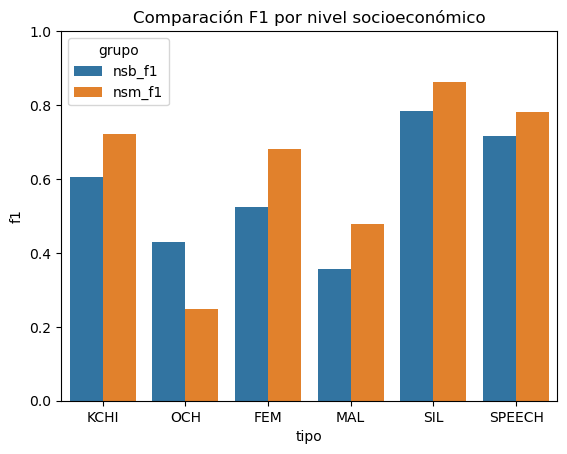

In [121]:
df_plot = df_comp.reset_index().rename(columns={"index": "tipo"})

import seaborn as sns
import matplotlib.pyplot as plt

df_plot_melt = df_plot.melt(
    id_vars="tipo",
    value_vars=["nsb_f1", "nsm_f1"],
    var_name="grupo",
    value_name="f1"
)

sns.barplot(data=df_plot_melt, x="tipo", y="f1", hue="grupo")

plt.title("Comparación F1 por nivel socioeconómico")
plt.ylim(0, 1)
plt.show()

# Parte 6. Multilabel → Single label

## REPORTE SINGLE LABEL

In [125]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# orden single-label correcto
labels_single = ["KCHI", "OCH", "MAL", "FEM", "SIL"]

# construir matrices base
y_true_base = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_MAL", "Elan_FEM", "Elan_SIL"]
].values

y_pred_base = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_MAL", "Diar_FEM", "Diar_SIL"]
].values

def multilabel_exclusivo_a_singlelabel(y_multilabel):
    single_labels = []
    for row in y_multilabel:
        indices = np.where(row == 1)[0]
        if len(indices) == 0:
            single_labels.append(-1)
        elif len(indices) == 1:
            single_labels.append(indices[0])
        else:
            # si hubiera más de una clase positiva en una fila "exclusiva",
            # tomar la primera y dejar advertencia conceptual
            single_labels.append(indices[0])
    return np.array(single_labels)

y_true = multilabel_exclusivo_a_singlelabel(y_true_base)
y_pred = multilabel_exclusivo_a_singlelabel(y_pred_base)

valid_indices = (y_true != -1) & (y_pred != -1)
y_true = y_true[valid_indices]
y_pred = y_pred[valid_indices]

print("\nReporte single-label:")

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(labels_single))),
    target_names=labels_single,
    zero_division=0,
    output_dict=True
)

df_report_single = pd.DataFrame(report).T

cols = ["precision", "recall", "f1-score"]
df_report_single[cols] = (df_report_single[cols] * 100).round(1).astype(str) + "%"

print(df_report_single)


Reporte single-label:
             precision recall f1-score       support
KCHI             60.9%  77.9%    68.3%  3.146110e+05
OCH              35.9%  30.8%    33.2%  2.098830e+05
MAL              44.1%  45.2%    44.6%  1.947400e+05
FEM              54.2%  63.9%    58.6%  4.774300e+05
SIL              88.7%  82.0%    85.2%  1.961296e+06
accuracy         73.2%  73.2%    73.2%  7.316499e-01
macro avg        56.7%  59.9%    58.0%  3.157960e+06
weighted avg     74.4%  73.2%    73.5%  3.157960e+06


# Parte 7. Matriz de confusión global 

## PRECISIÓN

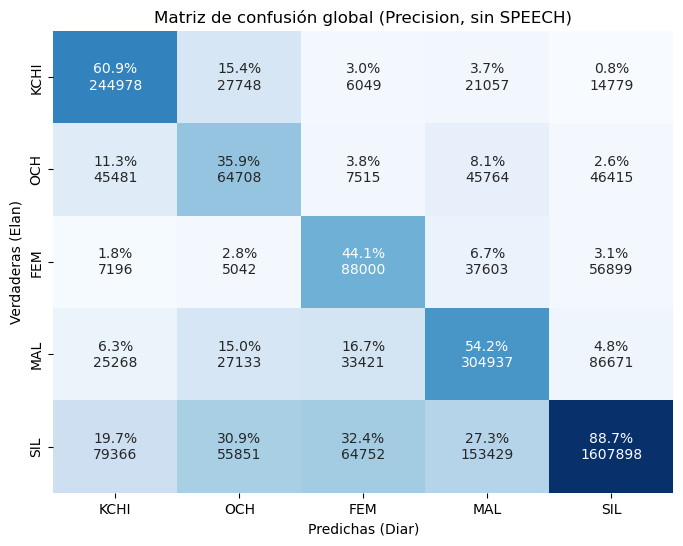

In [126]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labels_idx = list(range(len(labels)))

# matriz de conteos
cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)

# precision: normalizada por columnas
cm_precision = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="pred")

# sacar SPEECH solo del gráfico
if "SPEECH" in labels:
    idx_speech = labels.index("SPEECH")
    idx_keep = [i for i in range(len(labels)) if i != idx_speech]

    cm_counts_plot = cm_counts[np.ix_(idx_keep, idx_keep)]
    cm_precision_plot = cm_precision[np.ix_(idx_keep, idx_keep)]
    labels_plot = [labels[i] for i in idx_keep]
else:
    cm_counts_plot = cm_counts
    cm_precision_plot = cm_precision
    labels_plot = labels

cm_counts_df = pd.DataFrame(cm_counts_plot, index=labels_plot, columns=labels_plot)
cm_precision_df = pd.DataFrame(cm_precision_plot, index=labels_plot, columns=labels_plot)

annot = (
    (cm_precision_df * 100).round(1).astype(str)
    + "%"
    + "\n"
    + cm_counts_df.astype(int).astype(str)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_precision_df,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de confusión global (Precision, sin SPEECH)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_precision_sin_speech.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## RECALL 

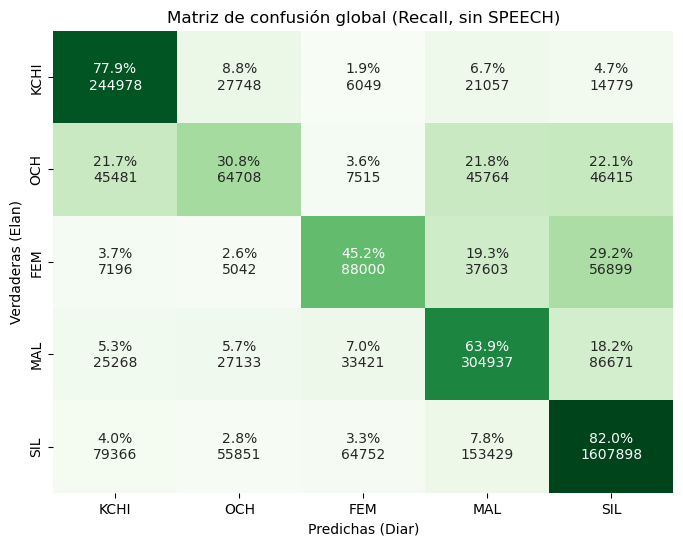

In [127]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labels_idx = list(range(len(labels)))

# matriz de conteos
cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)

# recall: normalizada por filas
cm_recall = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="true")

# sacar SPEECH solo del gráfico
if "SPEECH" in labels:
    idx_speech = labels.index("SPEECH")
    idx_keep = [i for i in range(len(labels)) if i != idx_speech]

    cm_counts_plot = cm_counts[np.ix_(idx_keep, idx_keep)]
    cm_recall_plot = cm_recall[np.ix_(idx_keep, idx_keep)]
    labels_plot = [labels[i] for i in idx_keep]
else:
    cm_counts_plot = cm_counts
    cm_recall_plot = cm_recall
    labels_plot = labels

cm_counts_df = pd.DataFrame(cm_counts_plot, index=labels_plot, columns=labels_plot)
cm_recall_df = pd.DataFrame(cm_recall_plot, index=labels_plot, columns=labels_plot)

annot = (
    (cm_recall_df * 100).round(1).astype(str)
    + "%"
    + "\n"
    + cm_counts_df.astype(int).astype(str)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_recall_df,
    annot=annot,
    fmt="",
    cmap="Greens",
    cbar=False
)

plt.title("Matriz de confusión global (Recall, sin SPEECH)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_recall_sin_speech.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Parte 8. Gráficos

In [129]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

# clases del análisis original single-label
# orden original de codificación:
# 0=KCHI, 1=OCH, 2=FEM, 3=MAL, 4=SIL
labels_base = ["KCHI", "OCH", "FEM", "MAL", "SIL"]

# filtrar válidos
valid_indices = (y_true != -1) & (y_pred != -1)
y_true_f = y_true[valid_indices]
y_pred_f = y_pred[valid_indices]

# binarizar clases base
classes_idx = list(range(len(labels_base)))  # [0,1,2,3,4]
y_true_multi_base = label_binarize(y_true_f, classes=classes_idx)
y_pred_multi_base = label_binarize(y_pred_f, classes=classes_idx)

# SPEECH = 1 si la clase es KCHI, OCH, FEM o MAL
speech_indices = [0, 1, 2, 3]

y_true_speech = (y_true_multi_base[:, speech_indices].sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_multi_base[:, speech_indices].sum(axis=1) > 0).astype(int)

# construir multilabel final SIN SIL y en el orden deseado:
# KCHI, OCH, MAL, FEM, SPEECH
y_true_multi = np.column_stack([
    y_true_multi_base[:, 0],  # KCHI
    y_true_multi_base[:, 1],  # OCH
    y_true_multi_base[:, 3],  # MAL
    y_true_multi_base[:, 2],  # FEM
    y_true_speech             # SPEECH
])

y_pred_multi = np.column_stack([
    y_pred_multi_base[:, 0],  # KCHI
    y_pred_multi_base[:, 1],  # OCH
    y_pred_multi_base[:, 3],  # MAL
    y_pred_multi_base[:, 2],  # FEM
    y_pred_speech             # SPEECH
])

labels = ["KCHI", "OCH", "MAL", "FEM", "SPEECH"]

print("shape y_true_multi:", y_true_multi.shape)
print("shape y_pred_multi:", y_pred_multi.shape)
print("labels:", labels)

report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    output_dict=True,
    zero_division=0
)

df_metrics = (
    pd.DataFrame(report)
    .transpose()
    .reset_index()
    .rename(columns={
        "index": "Tipo",
        "precision": "Precisión",
        "recall": "Recall",
        "f1-score": "F1-score",
        "support": "Support"
    })
)

filas_excluir = ["micro avg", "macro avg", "weighted avg", "samples avg"]
df_metrics = df_metrics[~df_metrics["Tipo"].isin(filas_excluir)].copy()

print(df_metrics)

shape y_true_multi: (3157960, 5)
shape y_pred_multi: (3157960, 5)
labels: ['KCHI', 'OCH', 'MAL', 'FEM', 'SPEECH']
     Tipo  Precisión    Recall  F1-score    Support
0    KCHI   0.608960  0.778670  0.683437   314611.0
1     OCH   0.358529  0.308305  0.331526   209883.0
2     MAL   0.541831  0.638705  0.586293   477430.0
3     FEM   0.440579  0.451885  0.446160   194740.0
4  SPEECH   0.737309  0.828888  0.780421  1196664.0


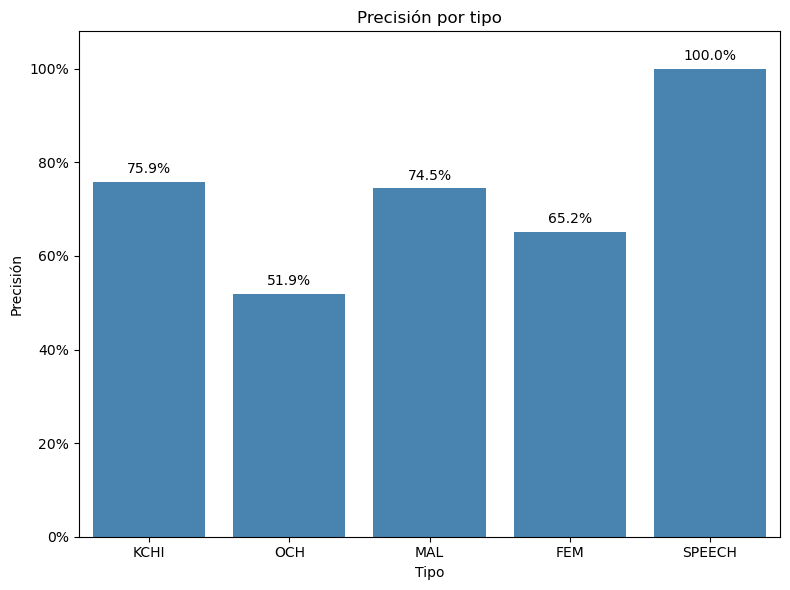

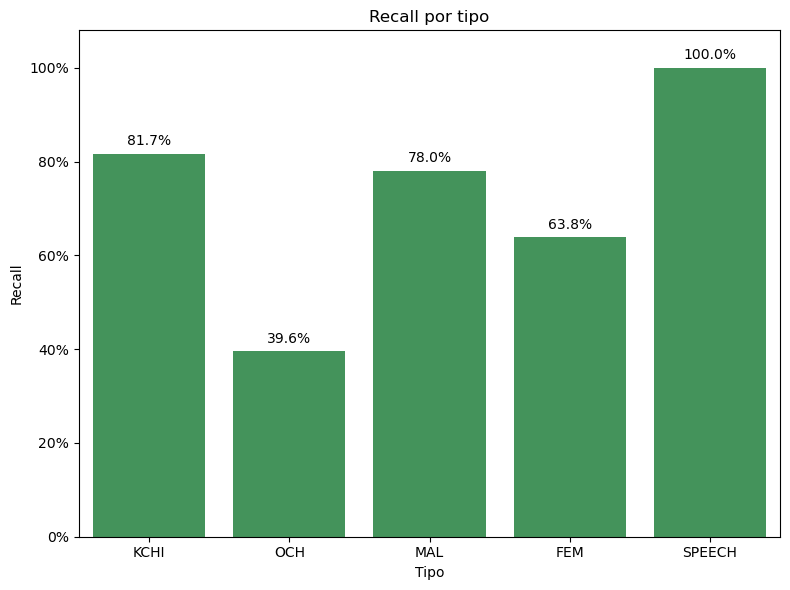

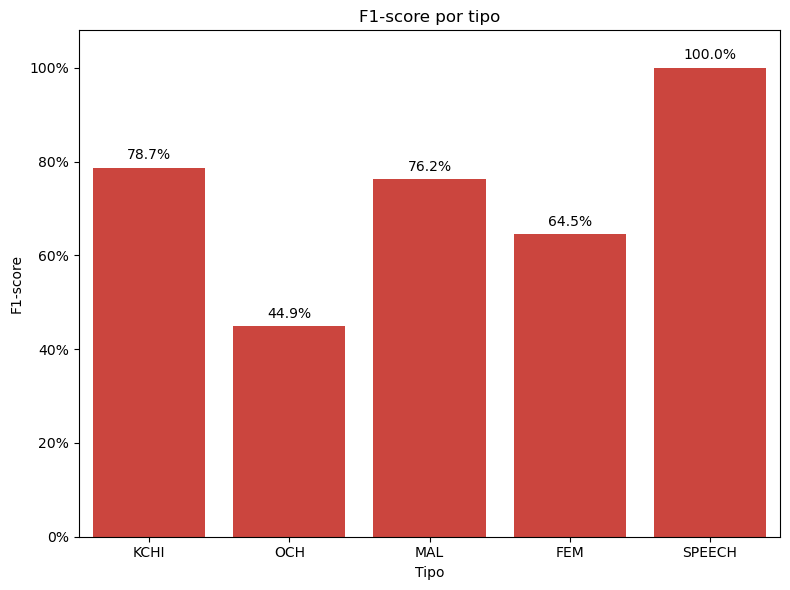

In [111]:
# asegurar orden consistente (CORRECTO)
orden = ["KCHI", "OCH", "MAL", "FEM", "SPEECH"]

df_metrics["Tipo"] = pd.Categorical(
    df_metrics["Tipo"],
    categories=orden,
    ordered=True
)
df_metrics = df_metrics.sort_values("Tipo").copy()

# un solo color por métrica
color_precision = sns.color_palette("Blues", 5)[3]
color_recall = sns.color_palette("Greens", 5)[3]
color_f1 = sns.color_palette("Reds", 5)[3]

plot_metrica(
    df_metrics,
    "Precisión",
    color_precision,
    "outputs/final_concats/precision_multilabel.png"
)

plot_metrica(
    df_metrics,
    "Recall",
    color_recall,
    "outputs/final_concats/recall_multilabel.png"
)

plot_metrica(
    df_metrics,
    "F1-score",
    color_f1,
    "outputs/final_concats/f1_multilabel.png"
)

# Parte 10. Ranking por chico

In [56]:
import pandas as pd
import re

tipos_para_ranking = ["FEM", "MAL", "KCHI", "OCH"]

df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv")

# =========================
# 0) Limpieza
# =========================
df["F1-score"] = pd.to_numeric(df["F1-score"], errors="coerce")
df_rank = df[df["Tipo"].isin(tipos_para_ranking)].copy()

# Extraer nombre base del chico desde strings tipo:
# alma-a1-nsb -> alma
# verag-a2-nsm -> verag
def extraer_chico_base(x):
    x = str(x).strip().lower()
    m = re.match(r"^(.*?)-a\d+-ns[mb]$", x)
    if m:
        return m.group(1)
    return x

df_rank["chico"] = df_rank["name"].apply(extraer_chico_base)

# =========================
# 1) Promedio por chico y tipo
# =========================
df_por_tipo = (
    df_rank
    .groupby(["chico", "Tipo"], as_index=False)
    .agg(f1_promedio=("F1-score", "mean"))
)

# =========================
# 2) Pivotear
# =========================
df_pivot = df_por_tipo.pivot(
    index="chico",
    columns="Tipo",
    values="f1_promedio"
).reset_index()

df_pivot = df_pivot.rename(columns={
    "FEM": "f1_FEM",
    "MAL": "f1_MAL",
    "KCHI": "f1_KCHI",
    "OCH": "f1_OCH"
})

# Asegurar columnas aunque falte alguna
for col in ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]:
    if col not in df_pivot.columns:
        df_pivot[col] = pd.NA

# =========================
# 3) Promedio total
# =========================
columnas_f1 = ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]
df_pivot["f1_promedio_total"] = df_pivot[columnas_f1].mean(axis=1)

# =========================
# 4) ns_code por chico
# =========================
meta = (
    df_rank
    .groupby("chico", as_index=False)
    .agg(
        ns_code=("ns_code", lambda s: s.dropna().iloc[0] if not s.dropna().empty else pd.NA)
    )
)

df_final = df_pivot.merge(meta, on="chico", how="left")

# =========================
# 5) Map manual de corpus por chico
# =========================
map_corpus = {
    "alma": "raw_ROS",
    "amparol": "raw_ROS",
    "angelinap": "raw_ROS",
    "bautista": "segunda-vuelta/random",
    "bautistad": "segunda-vuelta/random",
    "biancak": "raw_ROS_HV",
    "brandona": "segunda-vuelta/highVol",
    "camilob": "segunda-vuelta/random",
    "camilop": "raw_ROS_HV",
    "dantec": "raw_ROS",
    "dantep": "raw_ROS_HV",
    "dianag": "raw_ROS_HV",
    "florl": "segunda-vuelta/random",
    "francescam": "raw_ROS_HV",
    "franciscop": "raw_ROS_HV",
    "gaell": "raw_ROS",
    "jeremiasc": "segunda-vuelta/highVol",
    "julietap": "raw_ROS_HV",
    "lisandroh": "raw_ROS",
    "lucasyoelp": "raw_ROS_HV",
    "lucior": "raw_ROS",
    "manuelc": "raw_ROS",
    "ummaq": "raw_ROS",
    "valentina": "segunda-vuelta/highVol",
    "valentinos": "raw_ROS",
    "verag": "raw_ROS_HV",
}

df_final["corpus"] = df_final["chico"].map(map_corpus)

# =========================
# 6) Ranking
# =========================
df_final = df_final.sort_values("f1_promedio_total", ascending=False).reset_index(drop=True)
df_final["ranking"] = df_final.index + 1

# =========================
# 7) Orden final
# =========================
df_final = df_final[
    [
        "ranking",
        "chico",
        "corpus",
        "ns_code",
        "f1_promedio_total",
        "f1_FEM",
        "f1_MAL",
        "f1_KCHI",
        "f1_OCH"
    ]
]

# =========================
# 8) Revisar faltantes
# =========================
faltan_corpus = df_final[df_final["corpus"].isna()]
if not faltan_corpus.empty:
    print("\nNombres sin corpus asignado:")
    print(faltan_corpus[["chico"]].drop_duplicates().sort_values("chico"))

# Guardar
df_final.to_csv("outputs/ranking_f1_por_chico.csv", index=False, encoding="utf-8-sig")

print(df_final.head(10))

C:\Users\pablo\AppData\Local\Temp\ipykernel_12400\1034180915.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv")


   ranking       chico      corpus ns_code  f1_promedio_total    f1_FEM  \
0        1        alma     raw_ROS     nsb           0.567843  0.624738   
1        2       verag  raw_ROS_HV     nsm           0.544746  0.819251   
2        3  franciscop  raw_ROS_HV     nsm           0.513893  0.744271   
3        4     amparol     raw_ROS     nsb           0.502191  0.564282   
4        5      dantep  raw_ROS_HV     nsm           0.492102  0.730624   
5        6      dianag  raw_ROS_HV     nsb           0.475131  0.673355   
6        7   lisandroh     raw_ROS     nsm           0.469679  0.614277   
7        8      lucior     raw_ROS     nsm           0.466533  0.679651   
8        9   angelinap     raw_ROS     nsm           0.464117  0.573500   
9       10    julietap  raw_ROS_HV     nsm           0.460615  0.685825   

     f1_MAL   f1_KCHI    f1_OCH  
0  0.464171  0.642668  0.539797  
1  0.562983  0.796750  0.000000  
2  0.483493  0.827808  0.000000  
3  0.426217  0.565517  0.452747  
4  0

In [57]:
df_final

,ranking,chico,corpus,ns_code,f1_promedio_total,f1_FEM,f1_MAL,f1_KCHI,f1_OCH
0,1,alma,raw_ROS,nsb,0.567843,0.624738,0.464171,0.642668,0.539797
1,2,verag,raw_ROS_HV,nsm,0.544746,0.819251,0.562983,0.796750,0.000000
2,3,franciscop,raw_ROS_HV,nsm,0.513893,0.744271,0.483493,0.827808,0.000000
3,4,amparol,raw_ROS,nsb,0.502191,0.564282,0.426217,0.565517,0.452747
4,5,dantep,raw_ROS_HV,nsm,0.492102,0.730624,0.666058,0.571727,0.000000
5,6,dianag,raw_ROS_HV,nsb,0.475131,0.673355,0.272314,0.550755,0.404101
6,7,lisandroh,raw_ROS,nsm,0.469679,0.614277,0.409740,0.495047,0.359653
7,8,lucior,raw_ROS,nsm,0.466533,0.679651,0.376634,0.597606,0.212243
8,9,angelinap,raw_ROS,nsm,0.464117,0.573500,0.445049,0.627462,0.210458
9,10,julietap,raw_ROS_HV,nsm,0.460615,0.685825,0.326197,0.830437,0.000000
